# Synthetic Graph Dynamics with KoopmanGraph

This notebook walks through an end-to-end workflow on a reproducible synthetic
spatiotemporal graph benchmark. We train a **GraphKoopmanModel** to learn
topology-aware dynamics and roll out future graph snapshots.

Koopman operator theory represents nonlinear dynamics as linear evolution in a
lifted (observable) space. KoopmanGraph combines that idea with Graph Neural
Networks so the lifting and decoding steps respect graph structure.

## The encode → Koopman step → decode workflow

Each prediction step follows three stages:

1. **Encode (lifting):** A GNN encoder maps physical node features
   $x_t \in \mathbb{R}^{N \times F}$ into a latent representation
   $z_t \in \mathbb{R}^{N \times d}$ while passing messages along edges.
2. **Linear advance (Koopman step):** A learned matrix $K$ propagates the
   latent state forward: $z_{t+1} \approx z_t K^\top$ (per node).
3. **Decode:** A symmetric GNN decoder maps $z_{t+1}$ back to predicted
   physical features $\hat{x}_{t+1}$.

Training aligns one-step predictions with observed snapshots and can add
forward-consistency losses so encoded states evolve linearly in latent space.

In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, LossWeights
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark

## Generate synthetic data

`SyntheticDynamicGraphBenchmark` produces a sequence of PyG `Data` snapshots
on a fixed path graph. Node features evolve via Laplacian diffusion with
global decay and optional Gaussian noise.

We use a uniform initial state with mild decay and diffusion so trajectories
start smoothly instead of showing a sharp first-step transient.

In [2]:
data_sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=20,
    num_timesteps=30,
    in_channels=3,
    topology="path",
    seed=42,
    initial_state="ones",
    decay_rate=0.99,
    diffusion_rate=0.1,
    noise_std=0.01,
)

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Nodes: {data_sequence.num_nodes}")
print(f"Feature dim: {data_sequence.in_channels}")
print(f"Edges: {data_sequence.edge_index.shape[1]}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")

Snapshots: 30
Nodes: 20
Feature dim: 3
Edges: 38
First snapshot shape: torch.Size([20, 3])


Plot a few node trajectories over time for the first feature channel.

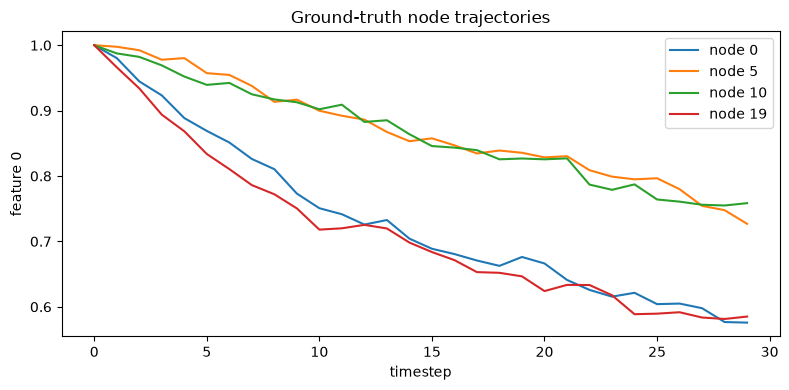

In [3]:
feature_idx = 0
node_ids = [0, 5, 10, 19]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for node_id in node_ids:
    values = torch.stack([snap.x[node_id, feature_idx] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"node {node_id}")
ax.set_xlabel("timestep")
ax.set_ylabel(f"feature {feature_idx}")
ax.set_title("Ground-truth node trajectories")
ax.legend()
fig.tight_layout()
plt.show()

## Build the model

We compose a GCN encoder, a learnable Koopman operator (inside
`GraphKoopmanModel`), and a symmetric GCN decoder.

In [4]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 64
out_channels = in_channels

encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)

print(model)

GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(3, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 3)
    )
  )
  (koopman): KoopmanOperator()
)


## Train

`fit` optimizes one-step reconstruction, forward consistency in latent
space, and an autoregressive rollout term that matches `predict`. The
rollout loss is important here because evaluation rolls out from a single
encoded initial snapshot rather than re-encoding ground truth each step.

In [5]:
predict_steps = 10
EPOCHS = 40 if os.environ.get("PYTEST_CURRENT_TEST") else 200
loss_weights = LossWeights(
    reconstruction=1.0,
    forward=1.0,
    rollout=1.0,
)

torch.manual_seed(0)
history = model.fit(
    data_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=predict_steps,
)

print(f"Initial loss: {history.loss[0]:.6f}")
print(f"Final loss: {history.loss[-1]:.6f}")

Initial loss: 1.768277
Final loss: 0.002713


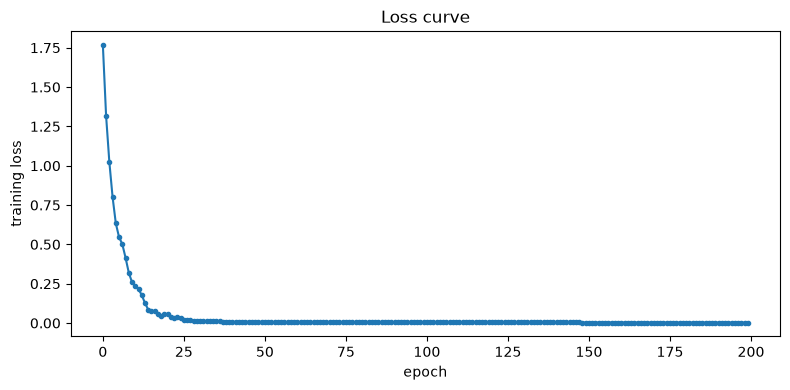

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.loss, marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("Loss curve")
fig.tight_layout()
plt.show()

## Predict future snapshots

`predict` encodes the initial graph once, applies the Koopman operator
autoregressively in latent space, and decodes after each step.

In [7]:
initial_graph = data_sequence[0]
future_graphs = model.predict(initial_graph, steps=predict_steps)

print(f"Predicted {len(future_graphs)} snapshots")
print(f"Prediction shape: {future_graphs[0].x.shape}")

ground_truth = data_sequence[1 : predict_steps + 1]
mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(future_graphs, ground_truth, strict=True)
        ]
    )
)
print(f"Mean one-step rollout MSE vs held-in sequence: {mse.item():.6f}")

Predicted 10 snapshots
Prediction shape: torch.Size([20, 3])
Mean one-step rollout MSE vs held-in sequence: 0.000668


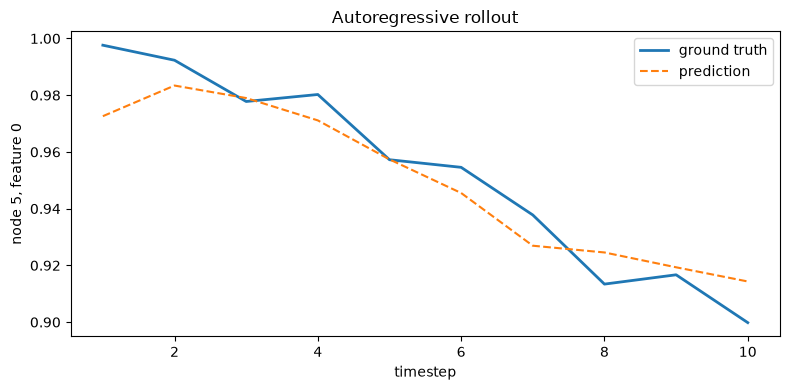

In [8]:
node_id = 5
pred_values = torch.stack([graph.x[node_id, feature_idx] for graph in future_graphs])
truth_values = torch.stack([graph.x[node_id, feature_idx] for graph in ground_truth])
pred_times = torch.arange(1, predict_steps + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pred_times, truth_values.numpy(), label="ground truth", linewidth=2)
ax.plot(pred_times, pred_values.numpy(), label="prediction", linestyle="--")
ax.set_xlabel("timestep")
ax.set_ylabel(f"node {node_id}, feature {feature_idx}")
ax.set_title("Autoregressive rollout")
ax.legend()
fig.tight_layout()
plt.show()

## Save and reload the trained model

`GraphKoopmanModel.save` writes learned weights **and** encoder/decoder
architecture configuration to a versioned `.pt` checkpoint.
`GraphKoopmanModel.load` reconstructs a ready-to-use model without manually
re-instantiating `GNNEncoder` / `GNNDecoder` classes.

The round-trip below checks that reloaded predictions match the original model.

In [9]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = Path(tmpdir) / "synthetic_model.pt"
    model.save(checkpoint_path)

    loaded_model = GraphKoopmanModel.load(checkpoint_path)
    reloaded_graphs = loaded_model.predict(initial_graph, steps=predict_steps)

max_delta = torch.max(
    torch.stack(
        [
            torch.max(torch.abs(original.x - reloaded.x))
            for original, reloaded in zip(future_graphs, reloaded_graphs, strict=True)
        ]
    )
)
print(f"Checkpoint: {checkpoint_path.name}")
print(f"Max |original - reloaded prediction|: {max_delta.item():.3e}")

Checkpoint: synthetic_model.pt
Max |original - reloaded prediction|: 0.000e+00


## Next steps

- See the [quickstart](https://koopmangraph.readthedocs.io/en/latest/quickstart.html)
  for a minimal script version of this workflow, including optional best-epoch
  checkpointing during `fit`.
- See [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) for the IEEE 118-bus smart grid tutorial.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss weights, early stopping, and encoder variants.
- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for METR-LA traffic
  speed forecasting on a road sensor network.
- See [`05_custom_data.ipynb`](05_custom_data.ipynb) for loading and formatting your
  own graph time-series data.